# Данные

In [1]:
from datasets import load_dataset
import pandas as pd
from sklearn.model_selection import train_test_split

/Users/george/ Учёба/NLP/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
ds = load_dataset("SetFit/ag_news")

train = ds["train"].to_pandas().copy()
test = ds["test"].to_pandas().copy()

test_2000, _ = train_test_split(
    test,
    train_size=2000,
    stratify=test["label"],
    random_state=42,
    shuffle=True
)

In [3]:
train.isna().sum()

text          0
label         0
label_text    0
dtype: int64

In [4]:
test.isna().sum()

text          0
label         0
label_text    0
dtype: int64

In [5]:
train

,text,label,label_text
0,Wall St. Bears Claw Back Into the Black (Reute...,2,Business
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2,Business
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2,Business
3,Iraq Halts Oil Exports from Main Southern Pipe...,2,Business
4,"Oil prices soar to all-time record, posing new...",2,Business
...,...,...,...
119995,Pakistan's Musharraf Says Won't Quit as Army C...,0,World
119996,Renteria signing a top-shelf deal Red Sox gene...,1,Sports
119997,Saban not going to Dolphins yet The Miami Dolp...,1,Sports
119998,Today's NFL games PITTSBURGH at NY GIANTS Time...,1,Sports


In [6]:
test_2000

,text,label,label_text
17,Mars Rovers Relay Images Through Mars Express ...,3,Sci/Tech
5460,Federated Department Stores Posts Profit NEW ...,2,Business
3264,CA aquires computer security firm Computer Ass...,2,Business
2945,Molson issues earnings warning MONTREAL - Mols...,2,Business
1184,"In the end, goofs sink Jays TORONTO -- All the...",1,Sports
...,...,...,...
6393,Nintendo Returns to Profit (AP) AP - Nintendo ...,3,Sci/Tech
7568,"Democrat Seeks to End Iowa, N.H. Power (AP) AP...",0,World
6677,Pinault-Printemps Redoute to sell holding in R...,2,Business
4535,NASCAR mourns plane crash victims Crews on all...,1,Sports


# Георгий (тема 4)

## Метод 4: Transformer fine-tuning

In [7]:
# Устанавливаем текстовые зависимости и удаляем torchvision: он не нужен для NLP,
# а в Colab иногда конфликтует с transformers/datasets.
import sys
import subprocess

subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q", "transformers", "datasets", "evaluate", "accelerate", "scikit-learn", "matplotlib"],
    check=True
)
subprocess.run(
    [sys.executable, "-m", "pip", "uninstall", "-y", "torchvision"],
    check=False
)

for module_name in list(sys.modules):
    if module_name.startswith("torchvision"):
        del sys.modules[module_name]

print("Dependencies are ready. torchvision is removed from this runtime.")

Dependencies are ready. torchvision is removed from this runtime.


In [8]:
import os
import random

os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["WANDB_DISABLED"] = "true"

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from datasets import load_dataset
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    Trainer,
    TrainingArguments,
    set_seed,
)

RANDOM_STATE = 42
set_seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

print("Device:", "cuda" if torch.cuda.is_available() else "cpu")

Device: cpu


In [9]:
# Используем уже подготовленные train, test и test_2000, если они есть в ноутбуке.
# Если этот раздел запускается отдельно, данные будут загружены заново.
if "train" not in globals() or "test" not in globals():
    ds = load_dataset("SetFit/ag_news")
    train = ds["train"].to_pandas().copy()
    test = ds["test"].to_pandas().copy()

if "test_2000" not in globals():
    test_2000, _ = train_test_split(
        test,
        train_size=2000,
        stratify=test["label"],
        random_state=RANDOM_STATE,
        shuffle=True,
    )

train = train[["text", "label"]].copy()
test_2000 = test_2000[["text", "label"]].copy()

train["label"] = train["label"].astype(int)
test_2000["label"] = test_2000["label"].astype(int)

print("train:", train.shape)
print("test_2000:", test_2000.shape)
print(test_2000["label"].value_counts().sort_index())

train: (120000, 2)
test_2000: (2000, 2)
label
0    500
1    500
2    500
3    500
Name: count, dtype: int64


In [10]:
label_names = ["World", "Sports", "Business", "Sci/Tech"]
id2label = {i: label for i, label in enumerate(label_names)}
label2id = {label: i for i, label in id2label.items()}

id2label

{0: 'World', 1: 'Sports', 2: 'Business', 3: 'Sci/Tech'}

In [11]:
# Train/validation split из исходного train.
method4_train_full, method4_val_full = train_test_split(
    train,
    test_size=0.1,
    stratify=train["label"],
    random_state=RANDOM_STATE,
    shuffle=True,
)

# Небольшие стратифицированные подвыборки для быстрого fine-tuning.
train_small, _ = train_test_split(
    method4_train_full,
    train_size=12000,
    stratify=method4_train_full["label"],
    random_state=RANDOM_STATE,
    shuffle=True,
)

val_small, _ = train_test_split(
    method4_val_full,
    train_size=2000,
    stratify=method4_val_full["label"],
    random_state=RANDOM_STATE,
    shuffle=True,
)

print("train_small:", train_small.shape)
print(train_small["label"].value_counts().sort_index())
print("val_small:", val_small.shape)
print(val_small["label"].value_counts().sort_index())
print("test_2000:", test_2000.shape)
print(test_2000["label"].value_counts().sort_index())

train_small: (12000, 2)
label
0    3000
1    3000
2    3000
3    3000
Name: count, dtype: int64
val_small: (2000, 2)
label
0    500
1    500
2    500
3    500
Name: count, dtype: int64
test_2000: (2000, 2)
label
0    500
1    500
2    500
3    500
Name: count, dtype: int64


In [12]:
model_name = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)

In [13]:
class AgNewsTorchDataset(torch.utils.data.Dataset):
    def __init__(self, dataframe, tokenizer, max_length=128):
        self.labels = dataframe["label"].astype(int).tolist()
        texts = dataframe["text"].astype(str).tolist()
        self.encodings = tokenizer(
            texts,
            padding="max_length",
            truncation=True,
            max_length=max_length,
        )

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {
            key: torch.tensor(values[idx])
            for key, values in self.encodings.items()
        }
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item


method4_train_dataset = AgNewsTorchDataset(train_small, tokenizer)
method4_val_dataset = AgNewsTorchDataset(val_small, tokenizer)
method4_test_dataset = AgNewsTorchDataset(test_2000, tokenizer)

len(method4_train_dataset), len(method4_val_dataset), len(method4_test_dataset)

(12000, 2000, 2000)

In [14]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=4,
    id2label=id2label,
    label2id=label2id,
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 8423.99it/s]


[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [15]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    return {
        "accuracy": accuracy_score(labels, predictions),
        "macro_f1": f1_score(labels, predictions, average="macro"),
        "macro_precision": precision_score(labels, predictions, average="macro", zero_division=0),
        "macro_recall": recall_score(labels, predictions, average="macro", zero_division=0),
    }

In [16]:
method4_training_args_common = dict(
    output_dir="./method_4_distilbert_checkpoints",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    logging_dir="./method_4_logs",
    logging_steps=100,
    save_total_limit=1,
    report_to="none",
    fp16=torch.cuda.is_available(),
)

try:
    method4_training_args = TrainingArguments(
        eval_strategy="epoch",
        **method4_training_args_common,
    )
except TypeError:
    method4_training_args = TrainingArguments(
        evaluation_strategy="epoch",
        **method4_training_args_common,
    )

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [17]:
# Не передаем tokenizer в Trainer: в новых версиях transformers этот аргумент устаревает.
method4_trainer = Trainer(
    model=model,
    args=method4_training_args,
    train_dataset=method4_train_dataset,
    eval_dataset=method4_val_dataset,
    compute_metrics=compute_metrics,
)

In [18]:
method4_train_output = method4_trainer.train()
method4_train_output

/Users/george/ Учёба/NLP/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Macro Precision,Macro Recall
1,0.291866,0.264018,0.920000,0.920098,0.921250,0.920000
2,0.189682,0.269308,0.920000,0.919791,0.923109,0.920000
3,0.119801,0.267509,0.925500,0.925419,0.925946,0.925500


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.10it/s]

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.10it/s]

...

/Users/george/ Учёба/NLP/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.27it/s]

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.26it/s]

TrainOutput(global_step=2250, training_loss=0.23189117749532065, metrics={'train_runtime': 1688.7651, 'train_samples_per_second': 21.317, 'train_steps_per_second': 1.332, 'total_flos': 1192249110528000.0, 'train_loss': 0.23189117749532065, 'epoch': 3.0})

In [19]:
method4_test_metrics = method4_trainer.evaluate(
    eval_dataset=method4_test_dataset,
    metric_key_prefix="test",
)

method4_test_metrics

/Users/george/ Учёба/NLP/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Epoch,Accuracy,Macro F1,Macro Precision,Macro Recall
0.119801,0.303400,3,0.919000,0.918800,0.919159,0.919000


{'test_loss': 0.30340033769607544,
 'test_accuracy': 0.919,
 'test_macro_f1': 0.9187997942832197,
 'test_macro_precision': 0.9191589488965997,
 'test_macro_recall': 0.919}

In [20]:
# Предсказания только для метода 4 на общем test_2000.
method4_predictions_output = method4_trainer.predict(method4_test_dataset)

method4_y_true = method4_predictions_output.label_ids
method4_y_pred = np.argmax(method4_predictions_output.predictions, axis=-1)

method4_classification_report = classification_report(
    method4_y_true,
    method4_y_pred,
    labels=[0, 1, 2, 3],
    target_names=label_names,
    digits=4,
)

print(method4_classification_report)

/Users/george/ Учёба/NLP/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


              precision    recall  f1-score   support

       World     0.9249    0.9360    0.9304       500
      Sports     0.9820    0.9800    0.9810       500
    Business     0.8943    0.8460    0.8695       500
    Sci/Tech     0.8755    0.9140    0.8943       500

    accuracy                         0.9190      2000
   macro avg     0.9192    0.9190    0.9188      2000
weighted avg     0.9192    0.9190    0.9188      2000



,pred_World,pred_Sports,pred_Business,pred_Sci/Tech
true_World,468,4,17,11
true_Sports,5,490,3,2
true_Business,22,3,423,52
true_Sci/Tech,11,2,30,457


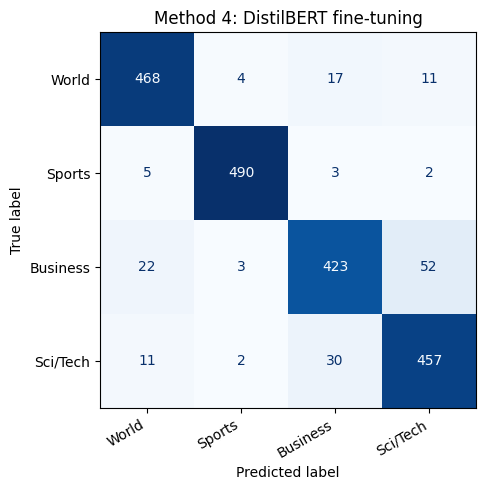

Saved: method_4_confusion_matrix.csv
Saved: method_4_confusion_matrix.png


In [21]:
# Confusion matrix только для метода 4.
method4_cm = confusion_matrix(method4_y_true, method4_y_pred, labels=[0, 1, 2, 3])
method4_confusion_matrix = pd.DataFrame(
    method4_cm,
    index=[f"true_{name}" for name in label_names],
    columns=[f"pred_{name}" for name in label_names],
)

display(method4_confusion_matrix)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=method4_cm,
    display_labels=label_names,
)
disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
ax.set_title("Method 4: DistilBERT fine-tuning")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("method_4_confusion_matrix.png", dpi=200, bbox_inches="tight")
plt.show()

method4_confusion_matrix.to_csv("method_4_confusion_matrix.csv")
print("Saved: method_4_confusion_matrix.csv")
print("Saved: method_4_confusion_matrix.png")

In [22]:
# Метрики только для метода 4.
method4_metrics = {
    "accuracy": accuracy_score(method4_y_true, method4_y_pred),
    "macro_f1": f1_score(method4_y_true, method4_y_pred, average="macro"),
    "macro_precision": precision_score(method4_y_true, method4_y_pred, average="macro", zero_division=0),
    "macro_recall": recall_score(method4_y_true, method4_y_pred, average="macro", zero_division=0),
}

transformer_results = pd.DataFrame([
    {
        "method_number": 4,
        "method": "Transformer fine-tuning",
        "model": model_name,
        "train_size": len(train_small),
        "validation_size": len(val_small),
        "test_size": len(test_2000),
        "accuracy": method4_metrics["accuracy"],
        "macro_f1": method4_metrics["macro_f1"],
        "macro_precision": method4_metrics["macro_precision"],
        "macro_recall": method4_metrics["macro_recall"],
    }
])

transformer_results

,method_number,method,model,train_size,validation_size,test_size,accuracy,macro_f1,macro_precision,macro_recall
0,4,Transformer fine-tuning,distilbert-base-uncased,12000,2000,2000,0.919,0.9188,0.919159,0.919


In [23]:
transformer_results.to_csv("method_4_transformer_results.csv", index=False)

with open("method_4_classification_report.txt", "w", encoding="utf-8") as f:
    f.write(method4_classification_report)

print("Saved: method_4_transformer_results.csv")
print("Saved: method_4_classification_report.txt")

Saved: method_4_transformer_results.csv
Saved: method_4_classification_report.txt


In [24]:
method4_model_dir = "./method_4_distilbert_ag_news"

method4_trainer.save_model(method4_model_dir)
tokenizer.save_pretrained(method4_model_dir)

print(f"Saved model and tokenizer to: {method4_model_dir}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.71it/s]

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.70it/s]

Saved model and tokenizer to: ./method_4_distilbert_ag_news


## Итог метода 4: Transformer fine-tuning

Метрики ниже относятся только к заданию 4: модель `distilbert-base-uncased`, fine-tuning через `Trainer`, оценка на общем `test_2000` из 2000 объектов. В этом ноутбуке нет zero-shot/few-shot блоков из задания 6.

### Итоговая таблица

| method_number | method | model | train_size | validation_size | test_size | accuracy | macro_f1 | macro_precision | macro_recall |
|---:|---|---|---:|---:|---:|---:|---:|---:|---:|
| 4 | Transformer fine-tuning | distilbert-base-uncased | 12000 | 2000 | 2000 | 0.9190 | 0.9188 | 0.9192 | 0.9190 |

### Classification report

| class | precision | recall | f1-score | support |
|---|---:|---:|---:|---:|
| World | 0.9249 | 0.9360 | 0.9304 | 500 |
| Sports | 0.9820 | 0.9800 | 0.9810 | 500 |
| Business | 0.8943 | 0.8460 | 0.8695 | 500 |
| Sci/Tech | 0.8755 | 0.9140 | 0.8943 | 500 |
| macro avg | 0.9192 | 0.9190 | 0.9188 | 2000 |

### Confusion matrix

| true \ pred | World | Sports | Business | Sci/Tech |
|---|---:|---:|---:|---:|
| World | 468 | 4 | 17 | 11 |
| Sports | 5 | 490 | 3 | 2 |
| Business | 22 | 3 | 423 | 52 |
| Sci/Tech | 11 | 2 | 30 | 457 |

Сохраненные файлы результата: `method_4_transformer_results.csv`, `method_4_classification_report.txt`, `method_4_confusion_matrix.csv`, `method_4_confusion_matrix.png`.